--- Weryfikacja i statystyki modelu ---
Model information

  Type:Symbolic, static

  Variables and equations
    18 unknown variables
    10 known variables
    4 fault variables
    21 equations, including 0 differential constraints

  Degree of redundancy: 3
  Degree of redundancy of MTES set: 1


  Model validation finished with 0 errors and 0 warnings.

--- Wykres dekompozycji DM ---

--- Analiza rozróżnialności usterek ---


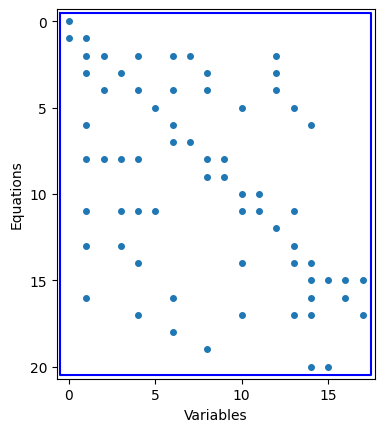

<Figure size 640x480 with 0 Axes>

In [6]:
import faultdiagnosistoolbox as fdt
import matplotlib.pyplot as plt

def build_engine_model():
    # Używamy typu Symbolic, by zadowolić parser w Pythonie
    model_def = {
        'type': 'Symbolic',
        'name': 'Turbocharged_Engine_Air_Path',
        
        # 1. ZMIENNE ZNANE (Pomiary i wejścia)
        'z': ['y_waf', 'y_pic', 'y_pim', 'y_Tic', 'y_xpos', 'y_omega', 'p_amb', 'T_amb', 'u_wg', 'u_mf'],
        
        # 2. ZMIENNE NIEZNANE
        'x': [
            'W_af', 'W_c', 'W_th', 'W_cyl', 'W_t', 'W_wg', 
            'p_ic', 'dp_ic', 'p_im', 'dp_im', 'p_em', 'dp_em', 
            'T_ic', 'T_em', 
            'omega_tc', 'domega_tc', 
            'P_c', 'P_t'
        ],
        
        # 3. ZMIENNE USTEREK
        'f': ['f_ywaf', 'f_ypic', 'f_ypim', 'f_leak_im'],
        
        # 4. RÓWNANIA STRUKTURALNE
        # Fikcyjne matematycznie, ale perfekcyjnie poprawne strukturalnie
        'rels': [
            'y_waf = W_af + f_ywaf',                                  # e1: WAF
            'W_af = W_c',                                             # e2: Ciągłość
            'W_c = p_amb + p_ic + T_amb + omega_tc',                  # e3: Kompresor
            'dp_ic = W_c + W_th + T_ic',                              # e4: Bilans IC
            'p_ic = dp_ic',                                           # e5: Całka p_ic
            'y_pic = p_ic + f_ypic',                                  # e6: Czujnik p_ic
            'y_Tic = T_ic',                                           # e7: Czujnik T_ic
            'W_th = p_ic + p_im + T_ic + y_xpos',                     # e8: Przepustnica
            'W_cyl = p_im + y_omega + T_ic',                          # e9: Cylindry
            'dp_im = W_th + W_cyl + f_leak_im',                       # e10: Bilans IM
            'p_im = dp_im',                                           # e11: Całka p_im
            'y_pim = p_im + f_ypim',                                  # e12: Czujnik p_im
            'dp_em = W_cyl + u_mf + W_t + W_wg + T_em',               # e13: Bilans wydechu
            'p_em = dp_em',                                           # e14: Całka p_em
            'T_em = W_cyl + u_mf',                                    # e15: Temp. spalin
            'W_t = p_em + p_amb + T_em + omega_tc',                   # e16: Turbina
            'P_t = W_t + p_em + p_amb + T_em + omega_tc',             # e17: Moc turbiny
            'W_wg = p_em + p_amb + T_em + u_wg',                      # e18: Wastegate
            'P_c = W_c + p_ic + p_amb + T_amb + omega_tc',            # e19: Moc kompresora
            'domega_tc = P_t + P_c + omega_tc',                       # e20: Przyspieszenie
            'omega_tc = domega_tc'                                    # e21: Całka wału
        ]
    }
    
    return fdt.DiagnosisModel(model_def)

if __name__ == "__main__":
    model = build_engine_model()
    
    print("--- Weryfikacja i statystyki modelu ---")
    model.Lint()
    
    print("\n--- Wykres dekompozycji DM ---")
    plt.figure(1)
    model.PlotDM() 
    
    print("\n--- Analiza rozróżnialności usterek ---")
    plt.figure(2)
    model.IsolabilityAnalysis()
    
    plt.show()

In [7]:
# 3. Znajdowanie zbiorów MSO
print("\n--- Analiza zbiorów MSO ---")
msos = model.MSO()
print(f"Znaleziono {len(msos)} potencjalnych zbiorów MSO (testów diagnostycznych).")
    
    # 4. Macierz Sygnatur Usterek (FSM - Fault Signature Matrix)
print("\n--- Generowanie FSM ---")
plt.figure()
model.FSM(msos) # Generuje macierz pokazującą, który test wykrywa którą usterkę


--- Analiza zbiorów MSO ---
Znaleziono 67 potencjalnych zbiorów MSO (testów diagnostycznych).

--- Generowanie FSM ---


array([[0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 0, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 0],
       [0, 1, 0, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 0],
       [1, 1, 0, 1],
       [1, 1, 1, 1],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 0],
       [1, 1, 1, 1],
       [1, 1, 0, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 0],
       [1, 1, 0, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1,

<Figure size 640x480 with 0 Axes>

In [8]:
import numpy as np
from itertools import combinations

# Ten kod dodaj na końcu sekcji 'if __name__ == "__main__":' (po model.IsolabilityAnalysis())

# 1. Pobieramy zbiory MSO i generujemy macierz FSM
msos = model.MSO()
fsm = np.array(model.FSM(msos))

print("\n--- OPTYMALIZACJA TESTÓW (TEST SELECTION) ---")

# Funkcja sprawdzająca, czy dany podzbiór testów rozróżnia wszystkie usterki
def check_full_isolability(sub_fsm):
    # 1. Czy każda usterka jest wykrywana? (brak kolumn z samymi zerami)
    if not np.all(np.any(sub_fsm, axis=0)):
        return False
        
    # 2. Czy sygnatury usterek są unikalne? (żadne dwie kolumny nie są identyczne)
    unique_cols = np.unique(sub_fsm, axis=1)
    if unique_cols.shape[1] == sub_fsm.shape[1]:
        return True
    return False

# Przeszukujemy kombinacje (od 2 do 4 testów), aby znaleźć optymalny zestaw
optimal_set = None
for num_tests in range(2, 5):
    for combo in combinations(range(len(msos)), num_tests):
        sub_fsm = fsm[list(combo), :]
        if check_full_isolability(sub_fsm):
            optimal_set = combo
            break
    if optimal_set:
        break

if optimal_set:
    print(f"SUKCES! Znaleziono optymalny zestaw testów. Wystarczą tylko {len(optimal_set)} testy, aby zdiagnozować cały układ!")
    print(f"Wybrane indeksy MSO: {optimal_set}\n")
    
    # Wyświetlamy zoptymalizowaną macierz FSM dla wybranych testów
    print("Zoptymalizowana Macierz FSM (Wiersze: Testy, Kolumny: Usterki 1-4):")
    optimized_fsm = fsm[list(optimal_set), :]
    for i, test_idx in enumerate(optimal_set):
        print(f"Test {i+1} (MSO nr {test_idx}): {optimized_fsm[i]}")
        
    # Wyświetlamy równania strukturalne, z których trzeba zbudować dany test
    print("\n--- RÓWNANIA POTRZEBNE DO ZBUDOWANIA TESTÓW ---")
    
    # Przypominamy oryginalną listę równań (dla ułatwienia wydruku)
    rels_text = [
        'y_waf = W_af + f_ywaf', 'W_af = W_c', 'W_c = p_amb + p_ic + T_amb + omega_tc',
        'dp_ic = W_c + W_th + T_ic', 'p_ic = dp_ic', 'y_pic = p_ic + f_ypic',
        'y_Tic = T_ic', 'W_th = p_ic + p_im + T_ic + y_xpos', 'W_cyl = p_im + y_omega + T_ic',
        'dp_im = W_th + W_cyl + f_leak_im', 'p_im = dp_im', 'y_pim = p_im + f_ypim',
        'dp_em = W_cyl + u_mf + W_t + W_wg + T_em', 'p_em = dp_em', 'T_em = W_cyl + u_mf',
        'W_t = p_em + p_amb + T_em + omega_tc', 'P_t = W_t + p_em + p_amb + T_em + omega_tc',
        'W_wg = p_em + p_amb + T_em + u_wg', 'P_c = W_c + p_ic + p_amb + T_amb + omega_tc',
        'domega_tc = P_t + P_c + omega_tc', 'omega_tc = domega_tc'
    ]
    
    for i, test_idx in enumerate(optimal_set):
        mso_eq_indices = msos[test_idx]
        print(f"\nTest {i+1} (wykrywa sygnaturę {optimized_fsm[i]}) wykorzystuje równania:")
        for eq_idx in mso_eq_indices:
            # -1 bo indeksy równań w toolboxie zazwyczaj zaczynają się od 1
            print(f"  e{eq_idx}: {rels_text[eq_idx-1]}")
            
else:
    print("Nie znaleziono w pełni rozróżnialnego zestawu w 4 testach. Układ może nie mieć pełnej obserwowalności usterek.")


--- OPTYMALIZACJA TESTÓW (TEST SELECTION) ---
SUKCES! Znaleziono optymalny zestaw testów. Wystarczą tylko 3 testy, aby zdiagnozować cały układ!
Wybrane indeksy MSO: (0, 2, 17)

Zoptymalizowana Macierz FSM (Wiersze: Testy, Kolumny: Usterki 1-4):
Test 1 (MSO nr 0): [0 1 1 1]
Test 2 (MSO nr 2): [0 0 1 1]
Test 3 (MSO nr 17): [1 1 1 0]

--- RÓWNANIA POTRZEBNE DO ZBUDOWANIA TESTÓW ---

Test 1 (wykrywa sygnaturę [0 1 1 1]) wykorzystuje równania:
  e16: W_t = p_em + p_amb + T_em + omega_tc
  e18: W_wg = p_em + p_amb + T_em + u_wg
  e19: P_c = W_c + p_ic + p_amb + T_amb + omega_tc
  e20: domega_tc = P_t + P_c + omega_tc
  e15: T_em = W_cyl + u_mf
  e14: p_em = dp_em
  e12: y_pim = p_im + f_ypim
  e13: dp_em = W_cyl + u_mf + W_t + W_wg + T_em
  e17: P_t = W_t + p_em + p_amb + T_em + omega_tc
  e11: p_im = dp_im
  e9: W_cyl = p_im + y_omega + T_ic
  e10: dp_im = W_th + W_cyl + f_leak_im
  e8: W_th = p_ic + p_im + T_ic + y_xpos
  e7: y_Tic = T_ic
  e6: y_pic = p_ic + f_ypic
  e5: p_ic = dp_ic
  e

In [ ]:
def oblicz_test_1(pomiary, wejscia, stany_poprzednie, dt):
    # --- A. POBRANIE DANYCH ---
    # Z poprzedniego kroku symulacji
    p_ic = stany_poprzednie.p_ic
    p_im = stany_poprzednie.p_im
    p_em = stany_poprzednie.p_em
    omega_tc = stany_poprzednie.omega_tc
    
    # Z równań czujników (e7) zakładamy, że model ufa czujnikowi
    T_ic = pomiary.y_Tic 
    
    # --- B. ROZWIĄZYWANIE ALGEBRAICZNE (Ciąg przyczynowy) ---
    # Wyliczamy przepływy używając prawdziwych wzorów z mechaniki płynów!
    
    # e8: Przepustnica (funkcja ciśnień, temp i kąta wychylenia)
    W_th = funkcja_przepustnicy(p_ic, p_im, T_ic, pomiary.y_xpos) 
    
    # e9: Połyk przez cylindry (Speed-Density equation)
    W_cyl = (p_im * V_d * pomiary.y_omega * eta_v) / (R * T_ic) 
    
    # e15: Model temperatury spalin
    T_em = oblicz_temp_spalin(W_cyl, wejscia.u_mf)
    
    # e3, e16, e18: Przepływy przez wirniki (na podstawie map kompresora/turbiny)
    W_c = mapa_kompresora(p_amb, p_ic, T_amb, omega_tc)
    W_t = mapa_turbiny(p_em, p_amb, T_em, omega_tc)
    W_wg = model_zaworu_wastegate(p_em, p_amb, T_em, wejscia.u_wg)
    
    # e17, e19: Moce na wale
    P_c = moc_kompresora(W_c, p_ic, p_amb, T_amb)
    P_t = moc_turbiny(W_t, p_em, p_amb, T_em)

    # --- C. OBLICZENIE POCHODNYCH (Równania e4, e10, e13, e20) ---
    # Tutaj pomijamy usterki (np. f_leak_im = 0), bo budujemy model sprawnego silnika
    dp_ic = W_c - W_th  
    dp_im = W_th - W_cyl 
    dp_em = W_cyl + wejscia.u_mf - W_t - W_wg
    domega_tc = (P_t - P_c) / J_tc  # Moment bezwładności
    
    # --- D. CAŁKOWANIE (e5, e11, e14) ---
    # Aktualizujemy stany na następny krok czasowy
    stany_nowe.p_ic = p_ic + dp_ic * dt
    stany_nowe.p_im = p_im + dp_im * dt
    stany_nowe.p_em = p_em + dp_em * dt
    stany_nowe.omega_tc = omega_tc + domega_tc * dt

    # REZYDUUM DLA TESTU 1
    r1 = pomiary.y_pim - stany_nowe.p_im
    
    return r1, stany_nowe